# Feature-based RBF residual GRAPE

This notebook tests the next residual idea:

```text
u -> nominal simulated trajectory -> physics-informed features -> RBF correction
```

The older RBF saw the raw 80 B-spline coefficients. That is hard because two pulses can be far in coefficient space but physically similar. Here the RBF sees lower-dimensional features such as integrated qubit excitation, photon-number timing, drive power, and pulse smoothness.

The optimizer still uses JAX autodifferentiation through the physics simulator and the learned correction.

In [2]:
from dataclasses import replace

import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

from hybrid_residual_grape import (
    FEATURE_NAMES,
    FockPhysicsModel,
    HybridGrapeConfig,
    PhysicsParams,
    RBFResidualConfig,
    SimulationConfig,
    append_dataset,
    empty_feature_rbf_model,
    feature_hybrid_probability_batch,
    fit_feature_rbf_residual,
    make_local_experiment_batch,
    optimize_feature_hybrid_grape,
    sample_binomial_measurements,
    trajectory_feature_matrix,
)
from hybrid_residual_grape.config import (
    khz_to_rad_per_us,
    qubit_t1_us,
    qubit_t2_us,
    storage_t1_us,
    storage_t2_us,
)
from hybrid_residual_grape.residual import measured_probability

jax.config.update("jax_enable_x64", True)

## Setup

`physics_model` is the model used by GRAPE and by the feature extractor. `true_model` is only the hidden simulator used here to mimic the experiment. On hardware, `measure_on_experiment` should be replaced by the OPX measurement call.

The hidden model includes small detunings, drive-scale errors, cavity self-Kerr, and shortened T1/T2. The nominal model omits these effects.

In [3]:
seed = 2026
key = jax.random.key(seed)

q = SimulationConfig(
    n_cav=25,
    target_n=2,
    initial_cavity_n=0,
    initial_qubit_state=0,
    t_drive=1.408,
    ndt_drive=80,
    num_coeffs=20,
    spline_degree=2,
    spline_skip_left=2,
    spline_skip_right=2,
    param_clip=2.0,
)

config_params = PhysicsParams()

nominal_params = replace(
    config_params,
    cavity_self_kerr=0.0,
    qubit_t1_us=None,
    qubit_t2_us=None,
    cavity_t1_us=None,
    cavity_t2_us=None,
)
physics_model = FockPhysicsModel(q, nominal_params)

lifetime_scale = 0.75
true_params = replace(
    config_params,
    chi=config_params.chi + khz_to_rad_per_us(3.0),
    cavity_self_kerr=config_params.cavity_self_kerr + khz_to_rad_per_us(0.12),
    cavity_detuning=khz_to_rad_per_us(5.0),
    qubit_detuning=khz_to_rad_per_us(-5.0),
    mu_qub=config_params.mu_qub * 1.010,
    mu_cav=config_params.mu_cav * 0.988,
    cavity_phase=0.025,
    qubit_t1_us=lifetime_scale * qubit_t1_us(),
    qubit_t2_us=lifetime_scale * qubit_t2_us(),
    cavity_t1_us=lifetime_scale * storage_t1_us(),
    cavity_t2_us=lifetime_scale * storage_t2_us(),
)
true_model = FockPhysicsModel(q, true_params)

print("parameter size:", physics_model.parameter_size)
print("feature size:", len(FEATURE_NAMES))
print("features:")
for name in FEATURE_NAMES:
    print(" -", name)
print("hidden collapse operators:", len(true_model.collapse_ops))

parameter size: 80
feature size: 13
features:
 - P_phys
 - mean_qubit_excitation
 - late_qubit_excitation
 - final_qubit_excitation
 - mean_photon_number
 - final_photon_number
 - mean_photon_variance
 - late_photon_number
 - target_photon_arrival_time
 - qubit_drive_power
 - cavity_drive_power
 - pulse_smoothness
 - max_coefficient
hidden collapse operators: 4


## Measurement hook

This function currently samples binomial counts from the hidden simulator. The optimizer only sees `successes / shots`, not the hidden true probability.

In [4]:
shot_time_us = 400.0


def measure_on_experiment(controls, key, shots):
    return sample_binomial_measurements(true_model, controls, key, shots=shots)

## Hyperparameters

The feature RBF length scale is in standardized feature units. A value around `1` means that points are considered similar if their trajectory features are within about one empirical standard deviation.

In [5]:
feature_rbf_config = RBFResidualConfig(
    max_centers=192,
    length_scale=1.2,
    ridge=3e-2,
    residual_clip=0.8,
    measurement_floor=1e-3,
)

baseline_config = HybridGrapeConfig(
    maxiter=320,
    memory_size=20,
    noise_samples=1,
    control_noise_std=0.0,
    residual_support_penalty=0.0,
    residual_size_penalty=0.0,
    amplitude_l2=3e-5,
    smoothness_l2=1e-4,
)

feature_grape_config = HybridGrapeConfig(
    maxiter=180,
    memory_size=18,
    noise_samples=5,
    control_noise_std=0.015,
    residual_support_penalty=0.03,
    residual_size_penalty=0.02,
    amplitude_l2=3e-5,
    smoothness_l2=1e-4,
)

num_rounds = 48
experiment_batch_size = 10
shots_per_pulse = 1200
validation_shots = 5000
local_noise_std = 0.035

print("measurements per round:", experiment_batch_size * shots_per_pulse)
print("measurement time per round [s]:", experiment_batch_size * shots_per_pulse * shot_time_us / 1e6)

measurements per round: 12000
measurement time per round [s]: 4.8


## Baseline: pure GRAPE on the nominal model

This is the comparison point: optimize the incomplete physics model, then evaluate the resulting pulse on the hidden true model.

In [6]:
key, init_key, grape_key = jax.random.split(key, 3)
initial_controls = 0.12 * jax.random.normal(init_key, (physics_model.parameter_size,))
initial_controls = jnp.clip(initial_controls, -0.4, 0.4)

empty_feature_residual = empty_feature_rbf_model(feature_rbf_config)
pure_controls, pure_history, pure_summary, key = optimize_feature_hybrid_grape(
    physics_model,
    empty_feature_residual,
    initial_controls,
    grape_key,
    baseline_config,
)

pure_physics = float(physics_model.photon_probability(pure_controls))
pure_true = float(true_model.photon_probability(pure_controls))
print("pure nominal-GRAPE predicted P_n:", pure_physics)
print("pure nominal-GRAPE hidden true P_n:", pure_true)

pure nominal-GRAPE predicted P_n: 0.9999290411349502
pure nominal-GRAPE hidden true P_n: 0.9388892804154161


## Closed-loop feature-RBF GRAPE

Each round:

1. Optimize the current hybrid model.
2. Measure the candidate pulse and local perturbations.
3. Recompute trajectory features for all measured pulses.
4. Fit the RBF correction in feature space.
5. Repeat from the latest candidate.

In [7]:
dataset_controls = None
dataset_successes = None
dataset_shots = None
dataset_physics = None

residual_model = empty_feature_rbf_model(feature_rbf_config)
current_controls = pure_controls
best_controls = pure_controls
best_measured = -1.0
best_true_diagnostic = pure_true

records = []
feature_snapshots = []
total_measurements = 0

for round_idx in tqdm(range(num_rounds), desc="feature-RBF rounds"):
    key, grape_key, measure_key = jax.random.split(key, 3)
    candidate, grape_history, summary, key = optimize_feature_hybrid_grape(
        physics_model,
        residual_model,
        current_controls,
        grape_key,
        feature_grape_config,
    )
    batch_controls, key = make_local_experiment_batch(
        candidate,
        key,
        batch_size=experiment_batch_size,
        noise_std=local_noise_std,
        param_clip=q.param_clip,
        include_center=True,
    )
    successes, shot_counts, true_probs, key = measure_on_experiment(
        batch_controls,
        measure_key,
        shots=shots_per_pulse,
    )
    physics_probs = physics_model.population_probability(batch_controls)
    dataset_controls, dataset_successes, dataset_shots, dataset_physics = append_dataset(
        dataset_controls,
        dataset_successes,
        dataset_shots,
        dataset_physics,
        batch_controls,
        successes,
        shot_counts,
        physics_probs,
    )
    total_measurements += int(jnp.sum(shot_counts))

    residual_model, dataset_features, dataset_physics_from_features = fit_feature_rbf_residual(
        physics_model,
        dataset_controls,
        dataset_successes,
        dataset_shots,
        feature_rbf_config,
    )
    hybrid_train, physics_train, support_train, residual_train, _ = feature_hybrid_probability_batch(
        physics_model,
        residual_model,
        dataset_controls,
    )
    measured_train = measured_probability(
        dataset_successes,
        dataset_shots,
        feature_rbf_config.measurement_floor,
    )

    val_successes, val_shots, val_true_prob, key = measure_on_experiment(
        candidate[None, :],
        key,
        shots=validation_shots,
    )
    measured_estimate = float(val_successes[0] / val_shots[0])
    true_diagnostic = float(val_true_prob[0])
    pred_hybrid, pred_physics, pred_support, pred_residual, candidate_features = feature_hybrid_probability_batch(
        physics_model,
        residual_model,
        candidate[None, :],
    )

    if measured_estimate > best_measured:
        best_measured = measured_estimate
        best_controls = candidate
    best_true_diagnostic = max(best_true_diagnostic, true_diagnostic)
    current_controls = candidate

    records.append(
        {
            "round": round_idx,
            "total_measurements": total_measurements,
            "measured_estimate": measured_estimate,
            "true_diagnostic": true_diagnostic,
            "best_measured": best_measured,
            "best_true_diagnostic": best_true_diagnostic,
            "pred_hybrid": float(pred_hybrid[0]),
            "pred_physics": float(pred_physics[0]),
            "support": float(pred_support[0]),
            "residual_logit": float(pred_residual[0]),
            "train_mae_physics": float(jnp.mean(jnp.abs(physics_train - measured_train))),
            "train_mae_hybrid": float(jnp.mean(jnp.abs(hybrid_train - measured_train))),
        }
    )
    feature_snapshots.append(candidate_features[0])

    tqdm.write(
        f"round {round_idx:02d} meas={measured_estimate:.4f} true={true_diagnostic:.4f} "
        f"pred={float(pred_hybrid[0]):.4f} support={float(pred_support[0]):.3f} "
        f"data={dataset_controls.shape[0]}"
    )

feature-RBF rounds:   2%|▏         | 1/48 [00:57<44:59, 57.44s/it]

round 00 meas=0.9328 true=0.9307 pred=0.9791 support=1.000 data=10


feature-RBF rounds:   4%|▍         | 2/48 [01:45<39:45, 51.86s/it]

round 01 meas=0.9370 true=0.9419 pred=0.9892 support=1.000 data=20


feature-RBF rounds:   6%|▋         | 3/48 [02:32<37:17, 49.72s/it]

...

round 45 meas=0.9190 true=0.9224 pred=0.9885 support=1.000 data=460


feature-RBF rounds:  98%|█████████▊| 47/48 [38:15<00:50, 50.14s/it]

round 46 meas=0.9246 true=0.9253 pred=0.9957 support=1.000 data=470


feature-RBF rounds: 100%|██████████| 48/48 [39:05<00:00, 48.86s/it]

round 47 meas=0.9262 true=0.9317 pred=0.9910 support=1.000 data=480


## Diagnostics

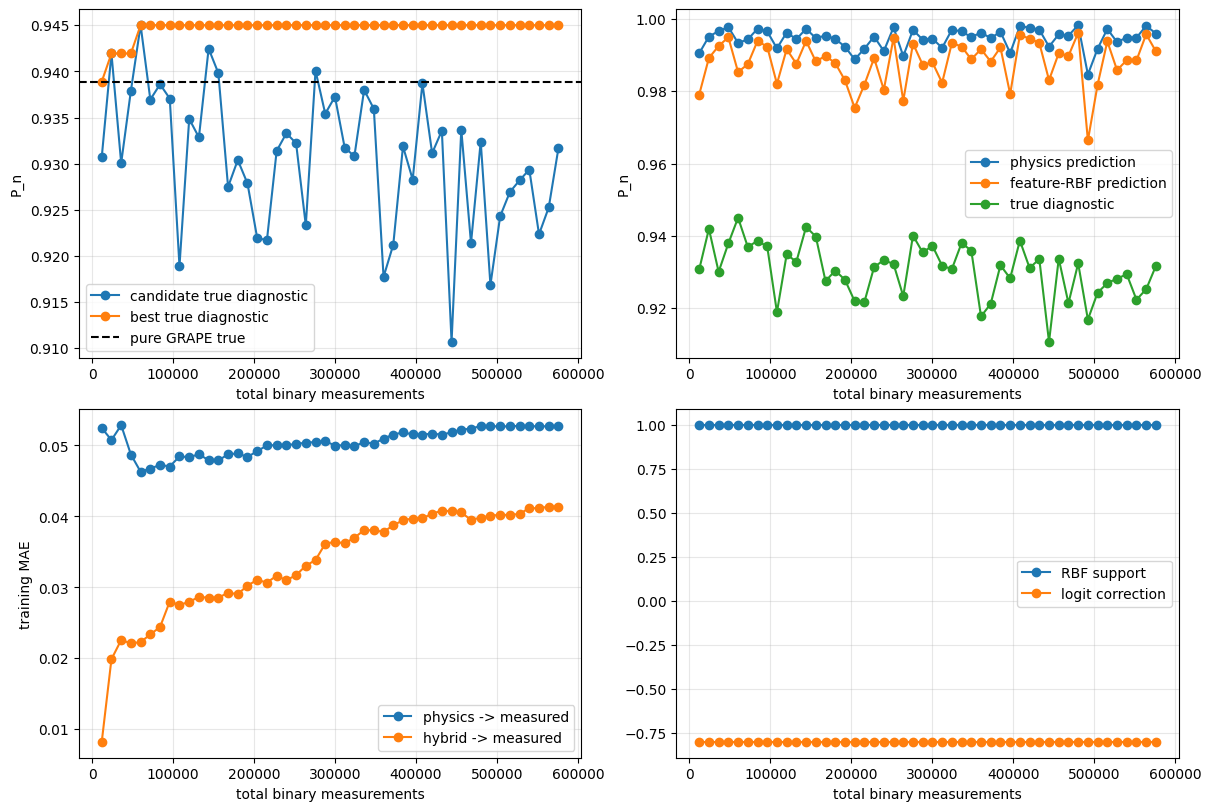

In [8]:
xs = jnp.array([r["total_measurements"] for r in records])

fig, axes = plt.subplots(2, 2, figsize=(12, 8), constrained_layout=True)

axes[0, 0].plot(xs, [r["true_diagnostic"] for r in records], "o-", label="candidate true diagnostic")
axes[0, 0].plot(xs, [r["best_true_diagnostic"] for r in records], "o-", label="best true diagnostic")
axes[0, 0].axhline(pure_true, color="black", linestyle="--", label="pure GRAPE true")
axes[0, 0].set_xlabel("total binary measurements")
axes[0, 0].set_ylabel("P_n")
axes[0, 0].legend()
axes[0, 0].grid(alpha=0.3)

axes[0, 1].plot(xs, [r["pred_physics"] for r in records], "o-", label="physics prediction")
axes[0, 1].plot(xs, [r["pred_hybrid"] for r in records], "o-", label="feature-RBF prediction")
axes[0, 1].plot(xs, [r["true_diagnostic"] for r in records], "o-", label="true diagnostic")
axes[0, 1].set_xlabel("total binary measurements")
axes[0, 1].set_ylabel("P_n")
axes[0, 1].legend()
axes[0, 1].grid(alpha=0.3)

axes[1, 0].plot(xs, [r["train_mae_physics"] for r in records], "o-", label="physics -> measured")
axes[1, 0].plot(xs, [r["train_mae_hybrid"] for r in records], "o-", label="hybrid -> measured")
axes[1, 0].set_xlabel("total binary measurements")
axes[1, 0].set_ylabel("training MAE")
axes[1, 0].legend()
axes[1, 0].grid(alpha=0.3)

axes[1, 1].plot(xs, [r["support"] for r in records], "o-", label="RBF support")
axes[1, 1].plot(xs, [r["residual_logit"] for r in records], "o-", label="logit correction")
axes[1, 1].set_xlabel("total binary measurements")
axes[1, 1].legend()
axes[1, 1].grid(alpha=0.3)

plt.show()

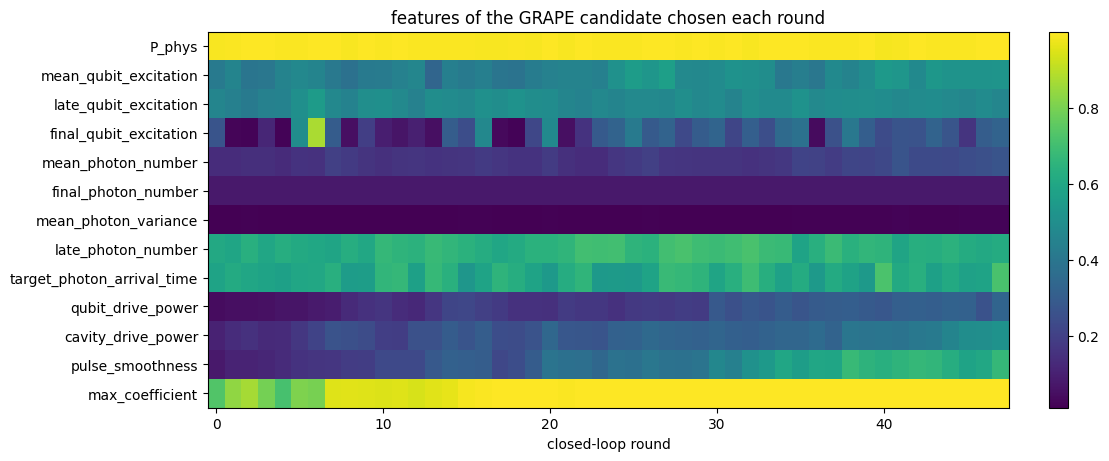

In [9]:
feature_array = jnp.stack(feature_snapshots)
fig, ax = plt.subplots(figsize=(11, 4.5), constrained_layout=True)
im = ax.imshow(feature_array.T, aspect="auto", interpolation="nearest")
ax.set_yticks(range(len(FEATURE_NAMES)))
ax.set_yticklabels(FEATURE_NAMES)
ax.set_xlabel("closed-loop round")
ax.set_title("features of the GRAPE candidate chosen each round")
fig.colorbar(im, ax=ax)
plt.show()